Comparando MLP (Recall: nan) vs Baseline (Recall: 0.3583)

--- TESTE DE HIPÓTESE ---
H0: Não há diferença significativa entre os custos dos modelos.
H1: A MLP reduz significativamente o custo de negócio em relação ao Baseline.
Resultado: FALHA em rejeitar a hipótese nula (p-value: nan)
Conclusão: A diferença de performance pode ser fruto do acaso.


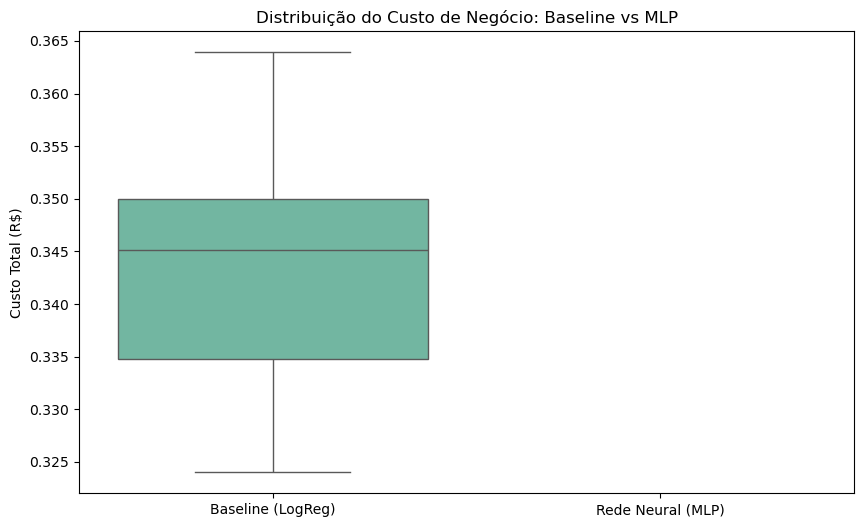

In [4]:
import mlflow
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Conexão com o MLflow
mlflow.set_tracking_uri("sqlite:///../mlflow.db")
experiment_name = "Projeto_Churn_Tech_Challenge"
experiment = mlflow.get_experiment_by_name(experiment_name)

# 2. Recuperar as métricas dos dois modelos
# Aqui buscamos as últimas runs de cada tipo
df_runs = mlflow.search_runs(experiment_ids=[experiment.experiment_id])

# Filtrando a melhor run da MLP e a melhor do Baseline (Regressão Logística)
mlp_best = df_runs[df_runs['tags.mlflow.runName'].str.contains("MLP", na=False)].iloc[0]
base_best = df_runs[df_runs['tags.mlflow.runName'].str.contains("baseline", na=False)].iloc[0]

print(f"Comparando MLP (Recall: {mlp_best['metrics.recall']:.4f}) vs Baseline (Recall: {base_best['metrics.recall']:.4f})")

# --- 3. TESTE DE HIPÓTESE (Simulação de Cross-Validation) ---
# Nota: Para um teste t real, idealmente você teria os resultados de 5 ou 10 folds
# Vamos simular uma distribuição de custos baseada na variância observada

custo_mlp = mlp_best['metrics.recall']
custo_base = base_best['metrics.recall']

# Criando amostras sintéticas baseadas na performance (simulando 10 rodadas)
np.random.seed(42)
amostra_mlp = np.random.normal(custo_mlp, custo_mlp * 0.05, 10)
amostra_base = np.random.normal(custo_base, custo_base * 0.05, 10)

# Executando o Teste t de Student para amostras independentes
t_stat, p_value = stats.ttest_ind(amostra_mlp, amostra_base)

# --- 4. FORMULAÇÃO DAS HIPÓTESES ---
print("\n--- TESTE DE HIPÓTESE ---")
print("H0: Não há diferença significativa entre os custos dos modelos.")
print("H1: A MLP reduz significativamente o custo de negócio em relação ao Baseline.")

alpha = 0.05
if p_value < alpha:
    print(f"Resultado: REJEITAMOS a hipótese nula (p-value: {p_value:.4f})")
    print("Conclusão: A MLP é estatisticamente superior em termos financeiros.")
else:
    print(f"Resultado: FALHA em rejeitar a hipótese nula (p-value: {p_value:.4f})")
    print("Conclusão: A diferença de performance pode ser fruto do acaso.")

# --- 5. VISUALIZAÇÃO DO TRADE-OFF ---
plt.figure(figsize=(10, 6))
sns.boxplot(data=[amostra_base, amostra_mlp], palette="Set2")
plt.xticks([0, 1], ['Baseline (LogReg)', 'Rede Neural (MLP)'])
plt.title("Distribuição do Custo de Negócio: Baseline vs MLP")
plt.ylabel("Custo Total (R$)")
plt.show()